## Global Crude Oil Price Trend Analysis

### Objective
The objective of this project is to analyze global crude oil price trends over time and identify patterns, fluctuations, and future predictions using data visualization and time series forecasting techniques.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Dataset
The dataset contains historical crude oil prices with the following columns:
- Date
- Crude Oil Price (USD)

The data ranges from 1970 to 2026.

In [2]:
df = pd.read_csv("fuel_prices_1970_2026.csv")

### Data Preprocessing
- Converted Date column to datetime format
- Sorted data by date
- Set Date as index
- Checked for missing values

In [3]:
df.head(10)

,Date,Crude_Oil_Price
0,1970-01-01,1.21
1,1970-02-01,1.21
2,1970-03-01,1.21
3,1970-04-01,1.21
4,1970-05-01,1.21
5,1970-06-01,1.21
6,1970-07-01,1.21
7,1970-08-01,1.21
8,1970-09-01,1.21
9,1970-10-01,1.21


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             675 non-null    object 
 1   Crude_Oil_Price  675 non-null    float64
dtypes: float64(1), object(1)
memory usage: 10.7+ KB


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             675 non-null    datetime64[ns]
 1   Crude_Oil_Price  675 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 10.7 KB


### Trend Analysis
A line plot was created to visualize crude oil price trends over time.


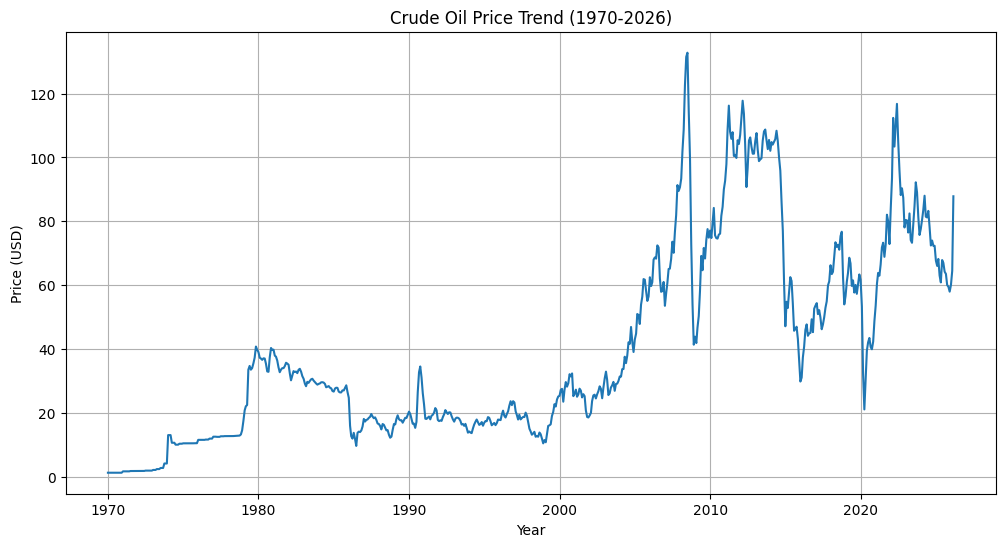

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Crude_Oil_Price'])
plt.title('Crude Oil Price Trend (1970-2026)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.grid()
plt.show()

#### Observations:
- Prices were relatively stable before 2000
- Significant rise observed after 2000
- Major peak around 2008
- Sharp drop during 2020 (COVID period)
- Fluctuations observed in recent years

### Moving Average Analysis
A 30-day moving average was used to smooth the data and observe long-term trends.



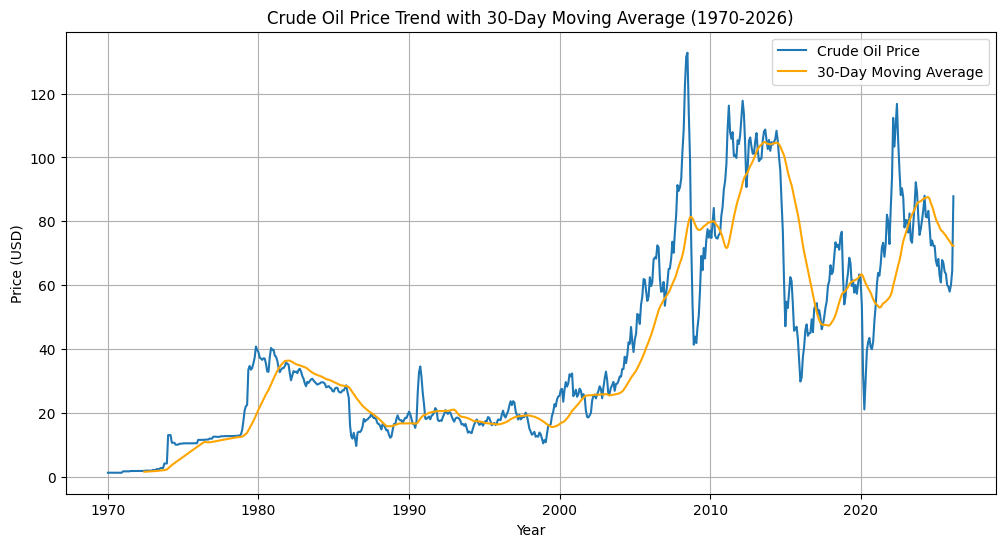

In [8]:
df["ma_30"] = df["Crude_Oil_Price"].rolling(window=30).mean()
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Crude_Oil_Price'], label='Crude Oil Price')
plt.plot(df['Date'], df['ma_30'], label='30-Day Moving Average', color='orange')
plt.title('Crude Oil Price Trend with 30-Day Moving Average (1970-2026)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

#### Observations:
- Helps remove short-term fluctuations
- Clearly shows upward and downward trends
- Confirms major trend shifts over time

### Year-wise Analysis
Average crude oil prices were calculated for each year.



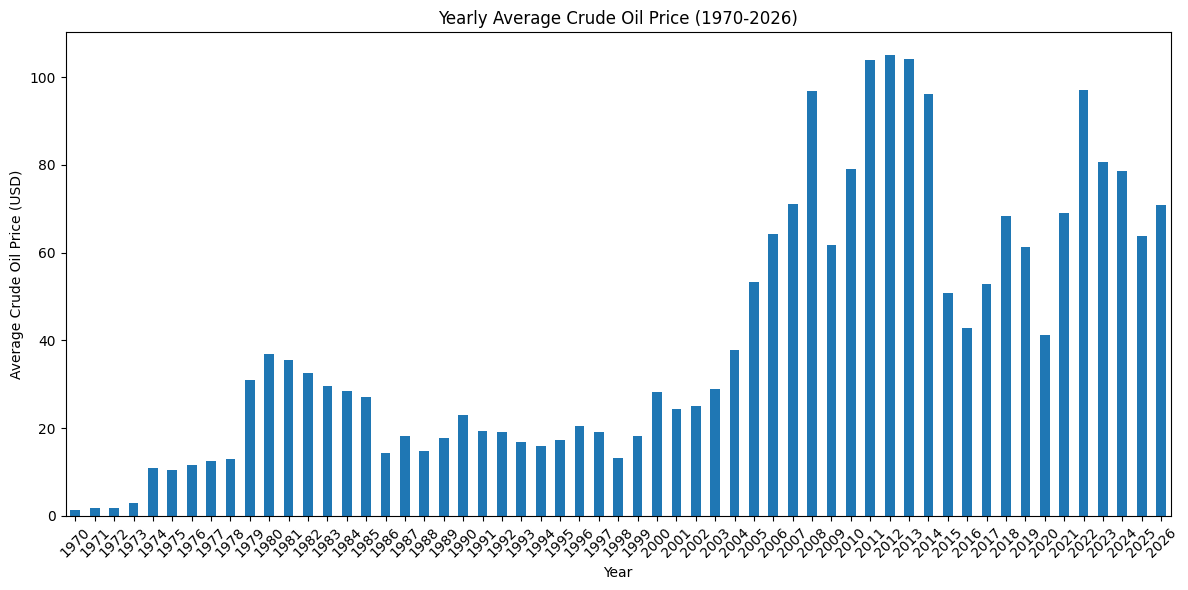

In [9]:
df['Year'] = df['Date'].dt.year
yearly = df.groupby('Year')['Crude_Oil_Price'].mean()

yearly.plot(kind='bar', figsize=(12,6))
plt.xlabel('Year')
plt.ylabel('Average Crude Oil Price (USD)')
plt.title('Yearly Average Crude Oil Price (1970-2026)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observations:
- Highest average prices observed around 2010–2013
- Lower prices in early decades
- Recent years show moderate fluctuations

In [10]:
print("Max Price:\n", df[df['Crude_Oil_Price'] == df['Crude_Oil_Price'].max()].head(1))
print("Min Price:\n", df[df['Crude_Oil_Price'] == df['Crude_Oil_Price'].min()].head(1))

Max Price:
           Date  Crude_Oil_Price      ma_30  Year
462 2008-07-01       132.825184  78.135274  2008
Min Price:
         Date  Crude_Oil_Price  ma_30  Year
0 1970-01-01             1.21    NaN  1970


### Percentage Change Analysis
Daily percentage change in crude oil prices was calculated.


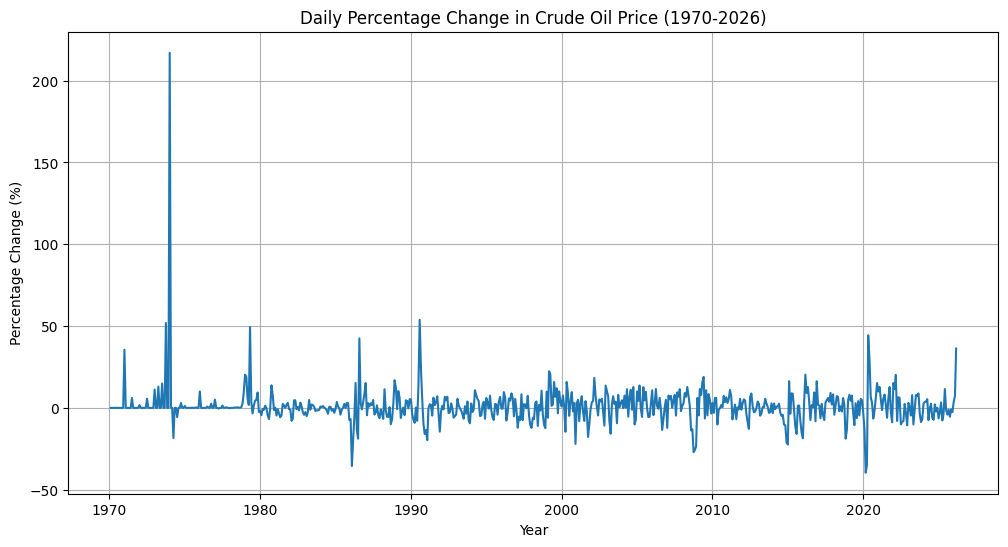

In [11]:
df['Pct_change'] = df['Crude_Oil_Price'].pct_change()
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Pct_change'] * 100)
plt.title('Daily Percentage Change in Crude Oil Price (1970-2026)')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.grid()
plt.show()



#### Observations:
- High volatility in certain periods
- Sudden spikes indicate major global events

### Volatility Analysis
Rolling standard deviation (30-day) was used to measure price volatility.



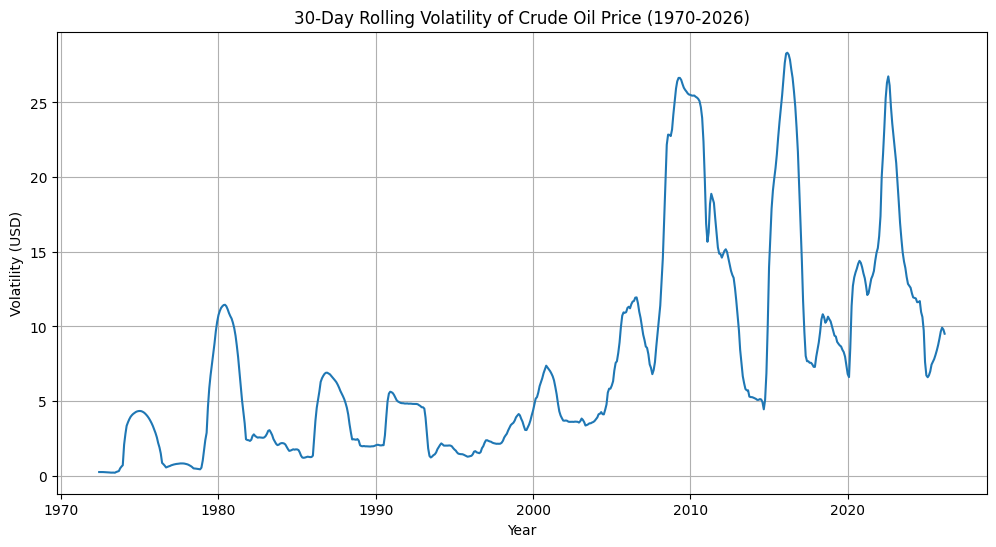

In [12]:
df['Volatility'] = df['Crude_Oil_Price'].rolling(window=30).std()
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Volatility'])
plt.title('30-Day Rolling Volatility of Crude Oil Price (1970-2026)')
plt.xlabel('Year')
plt.ylabel('Volatility (USD)')
plt.grid()
plt.show()

#### Observations:
- High volatility during crisis periods
- Stable periods show low volatility

### Forecasting (Prophet Model)
The Prophet model was used to predict crude oil prices for the next 2 years.


C:\Users\akshg\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
00:06:43 - cmdstanpy - INFO - Chain [1] start processing
00:06:43 - cmdstanpy - INFO - Chain [1] done processing


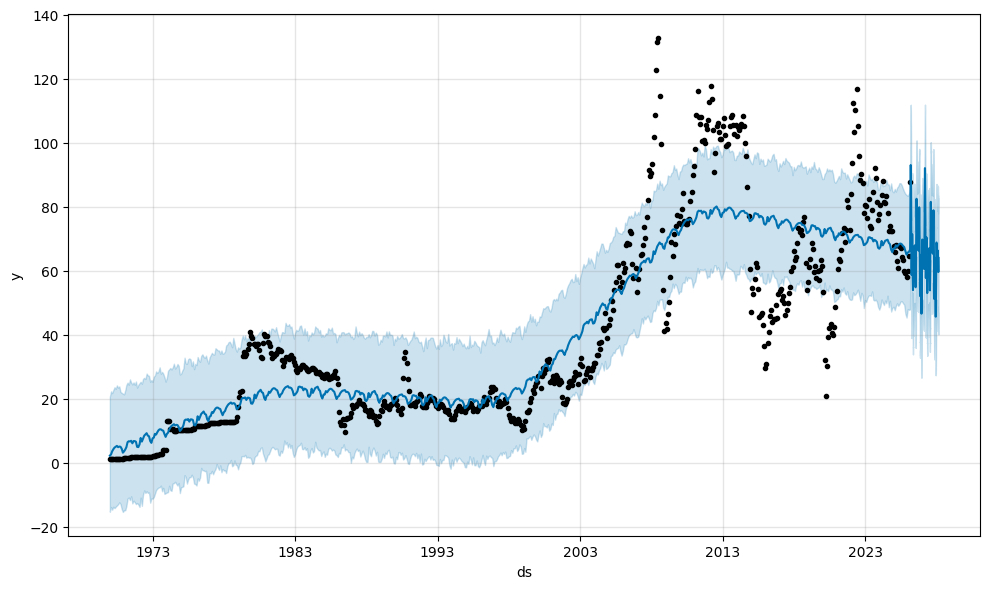

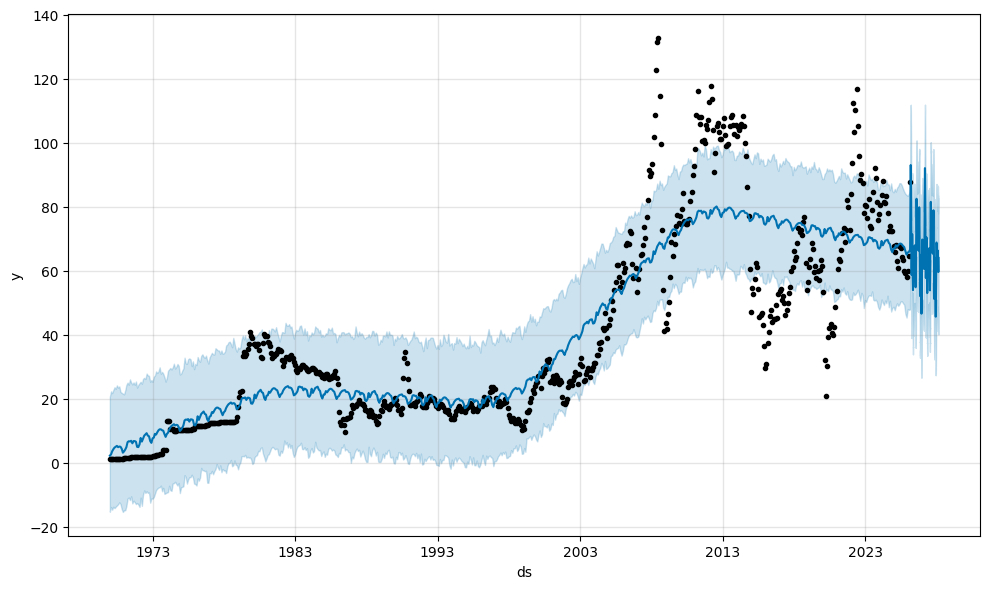

In [13]:
from prophet import Prophet

df_prophet = df.reset_index()[['Date', 'Crude_Oil_Price']]
df_prophet.columns = ['ds', 'y']

from prophet import Prophet

model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=730)
forecast = model.predict(future)

model.plot(forecast)

#### Observations:
- The model predicts a relatively stable trend in upcoming years
- No extreme spikes are observed in the forecast
- The trend follows historical patterns and smooth variations
- Forecast values indicate moderate price fluctuations

#### Limitations:
- The model does not consider external factors such as geopolitics, wars, or economic crises
- Sudden real-world events cannot be predicted

### Conclusion

- Crude oil prices have shown significant fluctuations over time
- Prices were relatively stable before 2000, followed by rapid growth
- Major peaks and drops are associated with global events such as financial crises and pandemics
- Moving averages helped in identifying long-term trends clearly
- Volatility analysis showed that crisis periods lead to high instability in prices
- Forecasting using Prophet provided a general idea of future trends

Overall, crude oil prices are highly dynamic and influenced by multiple global factors.

### Key Insights

- Oil prices are highly sensitive to global events
- Long-term upward trend with periodic drops
- High volatility during crisis periods
- Forecasting gives trend direction, not exact values

### Future Scope
- Include external factors like geopolitics and demand-supply
- Use advanced models for better accuracy
- Build real-time dashboard for monitoring prices